## Estadistica Aplicada

Secion 14 - 17 de Octubre

Bryan ALeajndro Estrada Rodriguez 1844554

Grupo: 042


In [1]:
# librerias Basicas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
# Especializadas
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Importamos modelo ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict


#Tamaño de graficas
plt.rcParams["figure.figsize"]= (10,6)
plt.rcParams["xtick.labelsize"]= 12
plt.rcParams["ytick.labelsize"]= 12
plt.rcParams["axes.labelsize"]= 12

In [3]:
igae_deses= pd.read_csv("https://raw.githubusercontent.com/jimmyzac/Estadistica-Aplicada-FCFM-UANL/main/bases_datos/igae_deses.csv")
igae_deses.head()

,meses,IGAE_DESES
0,1993/01,56.282290
1,1993/02,57.708594
2,1993/03,57.825254
3,1993/04,57.179522
4,1993/05,57.895451


IGAE (pib mensual) descentralizado
* ARIMA = Serie no tiene componente estacional
* SARIMA = Serie con componente estacional



**Requisitos:**

1. Formato fecha
2. Fecha sea el index
3. Asignar frecuencia


In [4]:
igae_deses["meses"] = pd.to_datetime(igae_deses["meses"], format="%Y/%m")
igae_deses.head()


,meses,IGAE_DESES
0,1993-01-01,56.282290
1,1993-02-01,57.708594
2,1993-03-01,57.825254
3,1993-04-01,57.179522
4,1993-05-01,57.895451


In [5]:
igae_deses = igae_deses.set_index("meses")
igae_deses.head()

,IGAE_DESES
meses,
1993-01-01,56.282290
1993-02-01,57.708594
1993-03-01,57.825254
1993-04-01,57.179522
1993-05-01,57.895451


In [6]:
#Asignacion de frecuencia
igae_deses = igae_deses.asfreq("MS")
igae_deses.index

DatetimeIndex(['1993-01-01', '1993-02-01', '1993-03-01', '1993-04-01',
               '1993-05-01', '1993-06-01', '1993-07-01', '1993-08-01',
               '1993-09-01', '1993-10-01',
               ...
               '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01',
               '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01',
               '2023-06-01', '2023-07-01'],
              dtype='datetime64[ns]', name='meses', length=367, freq='MS')

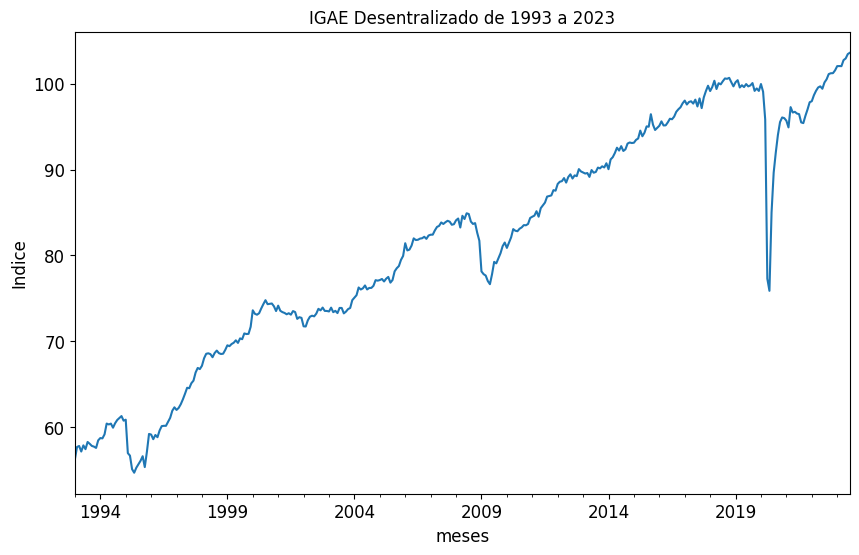

In [7]:
# Graficamos la serie de tiempo
igae_deses["IGAE_DESES"].plot()
plt.title("IGAE Desentralizado de 1993 a 2023")
plt.ylabel("Indice");

IGAE se comporta como una caminata aleatoria con deriva, sospechamos que es un proceso no estacionario



In [8]:
#prueba de dickey-filler aumentada
# H0: serie no estacionaria
# H1: Serie estacionaria
## ovalue < alpharechazamos H0
prueba_DFA = adfuller(igae_deses['IGAE_DESES'])
pvalue = prueba_DFA[1]
pvalue.round(2)

0.74

El pvalue de 0.74 No rechazamos H0, El IGAE('IGAE_DESES') es una serie No Estacionaria

Necesitamos calcular la primeras diferencias del IGAE $$\Delta_t = Y_t-t_{t-1}$$

In [9]:
#Primeras diferencias del IGAE
igae_deses['IGAE_DIFF'] = igae_deses['IGAE_DESES'].diff()
igae_deses.head()

,IGAE_DESES,IGAE_DIFF
meses,,
1993-01-01,56.282290,NaN
1993-02-01,57.708594,1.426305
1993-03-01,57.825254,0.116660
1993-04-01,57.179522,-0.645732
1993-05-01,57.895451,0.715929


<Axes: xlabel='meses'>

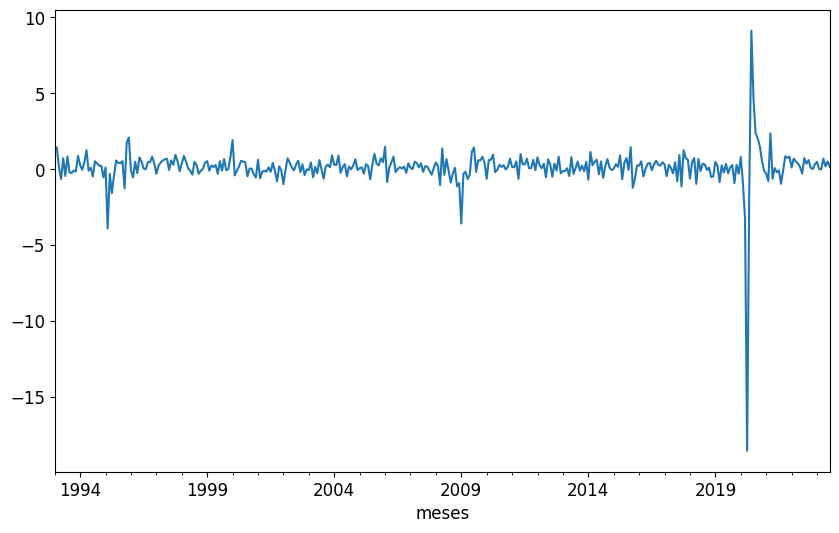

In [15]:
igae_deses['IGAE_DIFF'].plot()

In [16]:
# Prueba de Dickey-fuller aumentada para
#primeras diferencias del igae
prueba_DFA1 = adfuller(igae_deses['IGAE_DIFF'].dropna())
pvalue1 = prueba_DFA1[1]
pvalue.round(2)

0.74

El pvalue=0.0 rechazamos H0. Ñas primeras diferencias de igae('igae_diff') son una serie estacionaria
* IGAE = integrado(1)
* 1ras IGAE = integrado I(0)


Ya sabemos que las primeras diferencias del IGAE son un proceso estacionario, pero no sabemos que tipo de proceso estacionario es


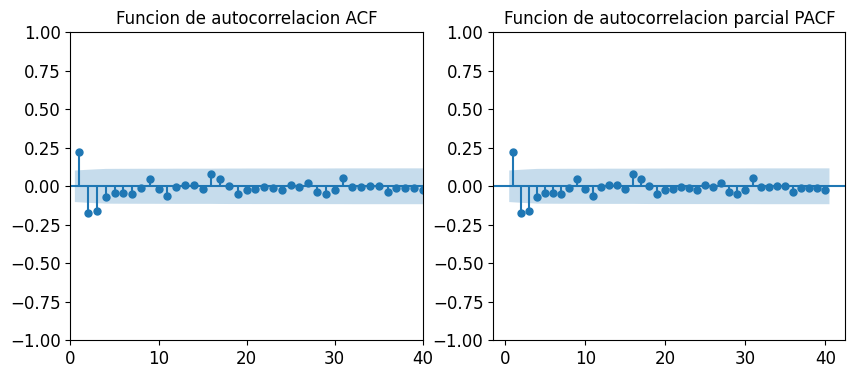

In [22]:
## Graficas de autocorrelacion
ig, ax=plt.subplots(1,2,figsize=(10,4))
## primer subgrafica
plot_acf(igae_deses['IGAE_DIFF'].dropna(), zero=False, lags=40, ax=ax[0], title='Funcion de autocorrelacion ACF')
ax[0].set_ylim(-1,1)
ax[0].set_xlim(0,40)

## primer subgrafica
plot_acf(igae_deses['IGAE_DIFF'].dropna(), zero=False, lags=40, ax=ax[1], title='Funcion de autocorrelacion parcial PACF')
ax[0].set_ylim(-1,1)
ax[0].set_xlim(0,40)
plt.show()

In [24]:
#suponer que IGAE_DIFF AR(1)=ARMA(1,0)=ARIMA(1,0,0)
#Estimar ARIMA (MCO)
modelo_prueba = ARIMA(igae_deses['IGAE_DIFF'],order = (1,0,0))
resultadop = modelo_prueba.fit()
print(resultadop.summary())

                               SARIMAX Results                                
Dep. Variable:              IGAE_DIFF   No. Observations:                  367
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -602.265
Date:                Tue, 17 Oct 2023   AIC                           1210.530
Time:                        22:06:03   BIC                           1222.246
Sample:                    01-01-1993   HQIC                          1215.185
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1303      0.118      1.100      0.271      -0.102       0.363
ar.L1          0.2219      0.027      8.070      0.000       0.168       0.276
sigma2         1.5731      0.021     74.742      0.0

El modelo estimado por MCO es:
$$Y_t=0.22 Y_{t-1} + ɛ_t$$

In [25]:
#suponer que IGAE_DIFF AR(1)=ARMA(1,0)=ARIMA(1,0,0)
#Estimar ARIMA (MCO)
modelo_prueba = ARIMA(igae_deses['IGAE_DIFF'],order = (2,0,0))
resultadop = modelo_prueba.fit()
print(resultadop.summary())

                               SARIMAX Results                                
Dep. Variable:              IGAE_DIFF   No. Observations:                  367
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -591.689
Date:                Tue, 17 Oct 2023   AIC                           1191.379
Time:                        22:06:13   BIC                           1207.000
Sample:                    01-01-1993   HQIC                          1197.585
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1292      0.110      1.179      0.238      -0.085       0.344
ar.L1          0.2747      0.027     10.270      0.000       0.222       0.327
ar.L2         -0.2367      0.017    -14.275      0.0

In [ ]:
ic = {}
for ar in range(7):
  for na in range(7):
    print(f"AR:{ar}, MA:{na}")
    modelo = ARIMA(igae_deses['IGAE_DIFF'].dropna(), order= (ar,0,na))
    resultado = modelo.fit()
    ic[(ar,na)] = [resultado.aic,resultado.bic]

ic =pd.DataFrame(ic, index=['AIC','BIC']).T
ic.index = ic.index.set_names(['AR','MA'])

In [36]:
ic

AIC          BIC
AR MA                          
0  0   1227.009237  1234.814504
   1   1200.924033  1212.631933
   2   1198.260034  1213.870567
   3   1189.688976  1209.202143
   4   1189.375837  1212.791637
   5   1190.171591  1217.490024
   6   1191.716873  1222.937940
1  0   1210.529688  1222.237588
   1   1200.876150  1216.486683
   2   1186.316694  1205.829861
   3   1187.415090  1210.830890
   4   1184.843163  1212.161596
   5   1186.229371  1217.450437
   6   1187.912586  1223.036286
2  0   1191.378555  1206.989088
   1   1188.692731  1208.205898
   2   1187.655051  1211.070851
   3   1189.183880  1216.502314
   4   1187.581069  1218.802135
   5   1188.741702  1223.865402
   6   1189.979649  1229.005982
3  0   1191.708073  1211.221239
   1   1183.372558  1206.788358
   2   1184.880343  1212.198776
   3   1186.729331  1217.950398
   4   1192.471498  1227.595198
   5   1190.726623  1229.752956
   6   1188.298744  1231.227711
4  0   1192.619318  1216.035118
   1   1185.021097  1212.339530
   2   1187.145017  1218.366084
   3   1188.606164  1223.729864
   4   1195.644320  1234.670654
   5   1195.132974  1238.061941
   6   1191.704006  1238.535606
5  0   1192.862955  1220.181389
   1   1186.855982  1218.077049
   2   1189.014715  1224.138415
   3   1190.509243  1229.535576
   4   1191.345475  1234.274441
   5   1194.549497  1241.381097
   6   1192.019715  1242.753948
6  0   1193.741006  1224.962073
   1   1188.297807  1223.421507
   2   1190.725064  1229.751398
   3   1192.248627  1235.177594
   4   1193.311519  1240.143119
   5   1199.988958  1250.723192
   6   1194.506435  1249.143302

In [37]:
ic.sort_values('AIC').head(1)
# Puede ser AIC o BIC

,,AIC,BIC
AR,MA,,
3,1,1183.372558,1206.788358


Las primeras diferencias de IGAE son un ARMA(3,1)
* Primeras Diferencias ARIMA (3,0,1)
* IGAE ARIMA (3, 1, 1)

In [38]:
from statsmodels.tsa import arima_process
## Modelo ARIMA para el IGAE
arima_model = ARIMA(igae_deses['IGAE_DESES'], order=(3,1,1))
results = arima_model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:             IGAE_DESES   No. Observations:                  367
Model:                 ARIMA(3, 1, 1)   Log Likelihood                -591.604
Date:                Tue, 17 Oct 2023   AIC                           1193.208
Time:                        22:31:27   BIC                           1212.721
Sample:                    01-01-1993   HQIC                          1200.962
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0175      0.232      4.384      0.000       0.563       1.472
ar.L2         -0.4222      0.072     -5.876      0.000      -0.563      -0.281
ar.L3          0.1048      0.089      1.176      0.2

In [39]:
#Pronosticar la serie original
igae_deses['modelo_arima']=results.predict()
igae_deses['modelo_arima'][0] = igae_deses['IGAE_DESES'][0]


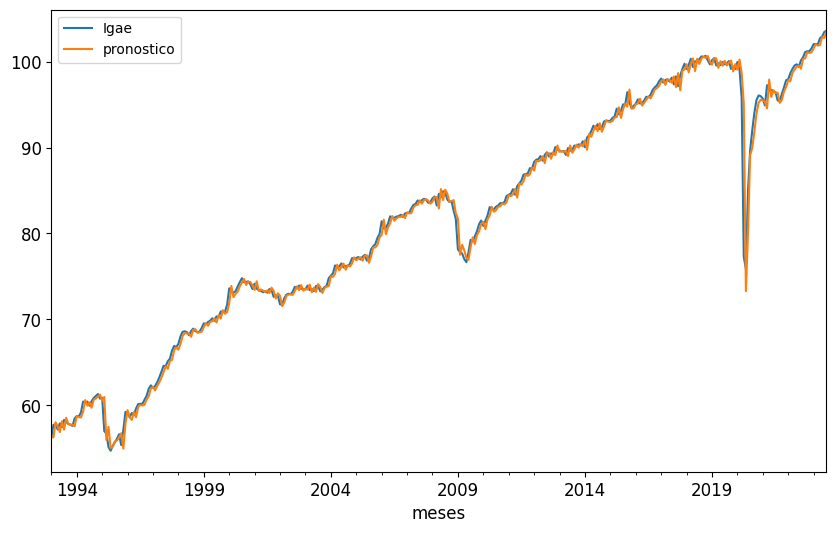

In [40]:
igae_deses['IGAE_DESES'].plot(label='Igae')
igae_deses['modelo_arima'].plot(label='pronostico')
plt.legend();

(606.0, 648.0)

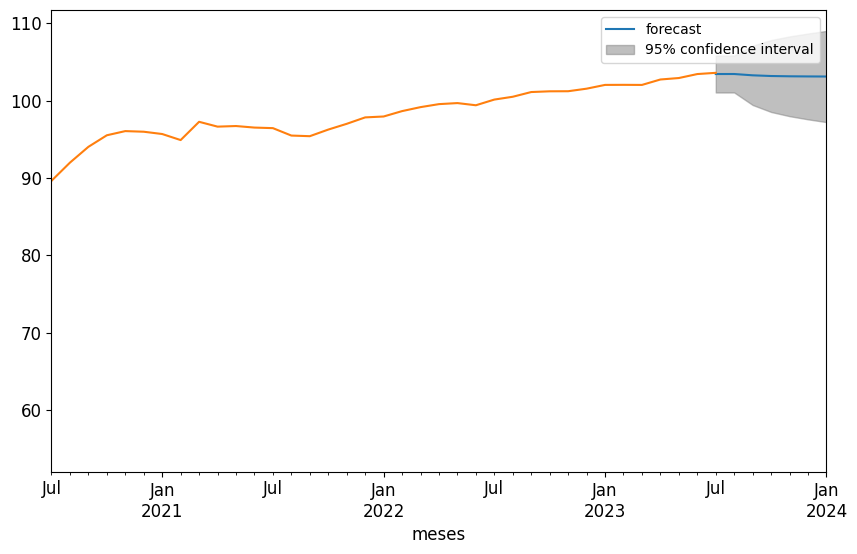

In [42]:
## Grafica del pronostico
plot_predict(results,start="2023-07-01", end="2024-01-01")
igae_deses['IGAE_DESES'].plot()
plt.xlim("2020-07-01","2024-01-01")
#Cuanto mas tiempo le as mas grande es el intervalo de confianza

In [44]:
igae_deses.tail(1)


,IGAE_DESES,IGAE_DIFF,modelo_arima
meses,,,
2023-07-01,103.596612,0.158524,103.442199


In [43]:
results.predict(start="2023-07-01",end="2025-10-01")

2023-07-01    103.442199
2023-08-01    103.443848
2023-09-01    103.275282
2023-10-01    103.184865
2023-11-01    103.148016
2023-12-01    103.131026
2024-01-01    103.119820
2024-02-01    103.111728
2024-03-01    103.106445
2024-04-01    103.103310
2024-05-01    103.101503
2024-06-01    103.100434
2024-07-01    103.099781
2024-08-01    103.099378
2024-09-01    103.099132
2024-10-01    103.098983
2024-11-01    103.098893
2024-12-01    103.098839
2025-01-01    103.098806
2025-02-01    103.098786
2025-03-01    103.098774
2025-04-01    103.098766
2025-05-01    103.098762
2025-06-01    103.098759
2025-07-01    103.098758
2025-08-01    103.098757
2025-09-01    103.098756
2025-10-01    103.098756
Freq: MS, Name: predicted_mean, dtype: float64

El pronostico de los modelos ARIMA es de corto plazo, confrome se pronostica mas en el futuro el intervalo de confianza se hace mas grande, tambien el pronostico converge a una constante lo que significa que tiene muy poca capacidad de pronosticar a mediano y largo plazo, en general se plantea que si es una ARIMA (3,1,1) pronostica bastante bien 3 periodos futuros, si es un ARIMA (2,1,4) pronostica

ARMA (3,1,1)
